In [1]:
#How random forests really work

In [2]:
from fastai.imports import *
np.set_printoptions(linewidth=130)

In [4]:
import os
from pathlib import Path

path = Path(r'C:\Users\modin\Downloads\titanic')
df = pd.read_csv(path/'train.csv')
tst_df = pd.read_csv(path/'test.csv')
modes = df.mode().iloc[0]

In [5]:
def proc_data(df):
    df['Fare'] = df.Fare.fillna(0)
    df.fillna(modes, inplace=True)
    df['LogFare'] = np.log1p(df['Fare'])
    df['Embarked'] = pd.Categorical(df.Embarked)
    df['Sex'] = pd.Categorical(df.Sex)

proc_data(df)
proc_data(tst_df)

In [6]:
cats=["Sex","Embarked"]
conts=['Age', 'SibSp', 'Parch', 'LogFare',"Pclass"]
dep="Survived"

In [7]:
df.Sex.head()

0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: category
Categories (2, str): ['female', 'male']

In [8]:
df.Sex.cat.codes.head()

0    1
1    0
2    0
3    0
4    1
dtype: int8

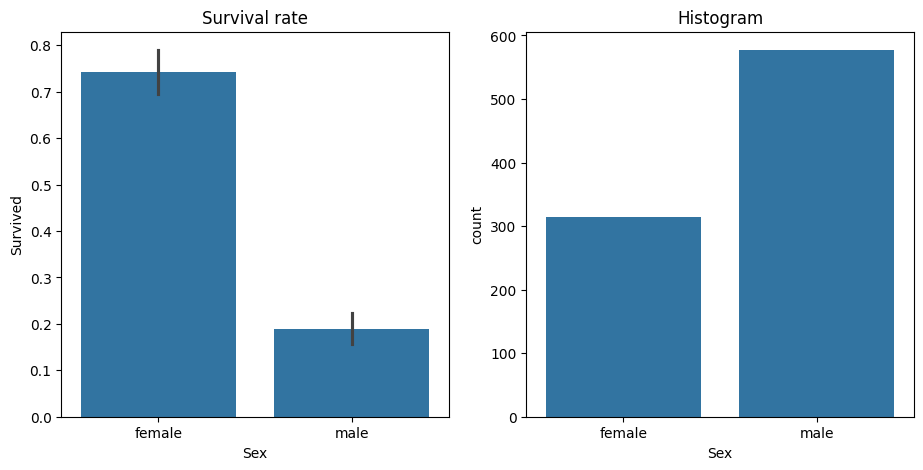

In [9]:
import seaborn as sns

fig,axs = plt.subplots(1,2, figsize=(11,5))
sns.barplot(data=df, y=dep, x="Sex", ax=axs[0]).set(title="Survival rate")
sns.countplot(data=df, x="Sex", ax=axs[1]).set(title="Histogram");

In [10]:
from numpy import random
from sklearn.model_selection import train_test_split

random.seed(42)
trn_df,val_df = train_test_split(df, test_size=0.25)
trn_df[cats] = trn_df[cats].apply(lambda x: x.cat.codes)
val_df[cats] = val_df[cats].apply(lambda x: x.cat.codes)

In [11]:
def xs_y(df):
    xs = df[cats+conts].copy()
    return xs,df[dep] if dep in df else None

trn_xs,trn_y = xs_y(trn_df)
val_xs,val_y = xs_y(val_df)

In [12]:
preds = val_xs.Sex==0

In [13]:

from sklearn.metrics import mean_absolute_error
mean_absolute_error(val_y, preds)

0.21524663677130046

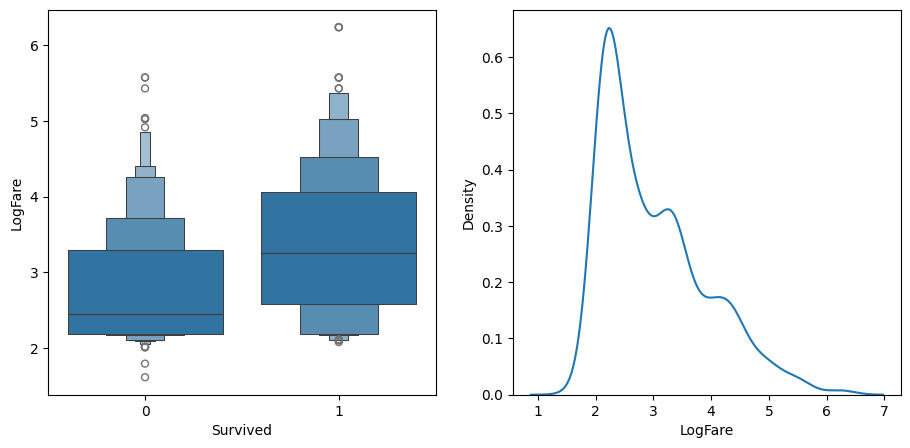

In [14]:
df_fare = trn_df[trn_df.LogFare>0]
fig,axs = plt.subplots(1,2, figsize=(11,5))
sns.boxenplot(data=df_fare, x=dep, y="LogFare", ax=axs[0])
sns.kdeplot(data=df_fare, x="LogFare", ax=axs[1]);

In [15]:
preds = val_xs.LogFare>2.7

In [16]:
mean_absolute_error(val_y, preds)

0.336322869955157

In [17]:
def _side_score(side, y):
    tot = side.sum()
    if tot<=1: return 0
    return y[side].std()*tot

In [18]:
    
def score(col, y, split):
    lhs = col<=split
    return (_side_score(lhs,y) + _side_score(~lhs,y))/len(y)


In [19]:
score(trn_xs["Sex"], trn_y, 0.5)

np.float64(0.40787530982063946)

In [20]:
score(trn_xs["LogFare"], trn_y, 2.7)

np.float64(0.47180873952099694)

In [21]:
def iscore(nm, split):
    col = trn_xs[nm]
    return score(col, trn_y, split)

from ipywidgets import interact
interact(nm=conts, split=15.5)(iscore);

interactive(children=(Dropdown(description='nm', options=('Age', 'SibSp', 'Parch', 'LogFare', 'Pclass'), value…

In [22]:
interact(nm=cats, split=2)(iscore);

interactive(children=(Dropdown(description='nm', options=('Sex', 'Embarked'), value='Sex'), IntSlider(value=2,…

In [23]:
nm = "Age"
col = trn_xs[nm]
unq = col.unique()
unq.sort()
unq


array([ 0.42,  0.67,  0.75,  0.83,  0.92,  1.  ,  2.  ,  3.  ,  4.  ,  5.  ,  6.  ,  7.  ,  8.  ,  9.  , 10.  , 11.  , 12.  ,
       13.  , 14.  , 14.5 , 15.  , 16.  , 17.  , 18.  , 19.  , 20.  , 21.  , 22.  , 23.  , 24.  , 24.5 , 25.  , 26.  , 27.  ,
       28.  , 28.5 , 29.  , 30.  , 31.  , 32.  , 32.5 , 33.  , 34.  , 34.5 , 35.  , 36.  , 36.5 , 37.  , 38.  , 39.  , 40.  ,
       40.5 , 41.  , 42.  , 43.  , 44.  , 45.  , 45.5 , 46.  , 47.  , 48.  , 49.  , 50.  , 51.  , 52.  , 53.  , 54.  , 55.  ,
       55.5 , 56.  , 57.  , 58.  , 59.  , 60.  , 61.  , 62.  , 64.  , 65.  , 70.  , 70.5 , 74.  , 80.  ])

In [24]:
scores = np.array([score(col, trn_y, o) for o in unq if not np.isnan(o)])
unq[scores.argmin()]

np.float64(6.0)

In [25]:
def min_col(df, nm):
    col,y = df[nm],df[dep]
    unq = col.dropna().unique()
    scores = np.array([score(col, y, o) for o in unq if not np.isnan(o)])
    idx = scores.argmin()
    return unq[idx],scores[idx]

min_col(trn_df, "Age")

(np.float64(6.0), np.float64(0.478316717508991))

In [26]:
cols = cats+conts
{o:min_col(trn_df, o) for o in cols}

{'Sex': (np.int8(0), np.float64(0.40787530982063946)),
 'Embarked': (np.int8(0), np.float64(0.47883342573147836)),
 'Age': (np.float64(6.0), np.float64(0.478316717508991)),
 'SibSp': (np.int64(4), np.float64(0.4783740258817434)),
 'Parch': (np.int64(0), np.float64(0.4805296527841601)),
 'LogFare': (np.float64(2.4390808375825834), np.float64(0.4620823937736597)),
 'Pclass': (np.int64(2), np.float64(0.46048261885806596))}

In [27]:
cols.remove("Sex")
ismale = trn_df.Sex==1
males,females = trn_df[ismale],trn_df[~ismale]

In [28]:
{o:min_col(males, o) for o in cols}

{'Embarked': (np.int8(0), np.float64(0.3875581870410906)),
 'Age': (np.float64(6.0), np.float64(0.3739828371010595)),
 'SibSp': (np.int64(4), np.float64(0.3875864227586273)),
 'Parch': (np.int64(0), np.float64(0.3874704821461959)),
 'LogFare': (np.float64(2.803360380906535), np.float64(0.3804856231758151)),
 'Pclass': (np.int64(1), np.float64(0.38155442004360934))}

In [29]:
{o:min_col(females, o) for o in cols}

{'Embarked': (np.int8(0), np.float64(0.4295252982857327)),
 'Age': (np.float64(50.0), np.float64(0.4225927658431649)),
 'SibSp': (np.int64(4), np.float64(0.42319212059713535)),
 'Parch': (np.int64(3), np.float64(0.4193314500446158)),
 'LogFare': (np.float64(4.256321678298823), np.float64(0.41350598332911376)),
 'Pclass': (np.int64(2), np.float64(0.3335388911567601))}

In [30]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz

m = DecisionTreeClassifier(max_leaf_nodes=4).fit(trn_xs, trn_y);

In [31]:
import graphviz

def draw_tree(t, df, size=10, ratio=0.6, precision=2, **kwargs):
    s=export_graphviz(t, out_file=None, feature_names=df.columns, filled=True, rounded=True,
                      special_characters=True, rotate=False, precision=precision, **kwargs)
    return graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', s))

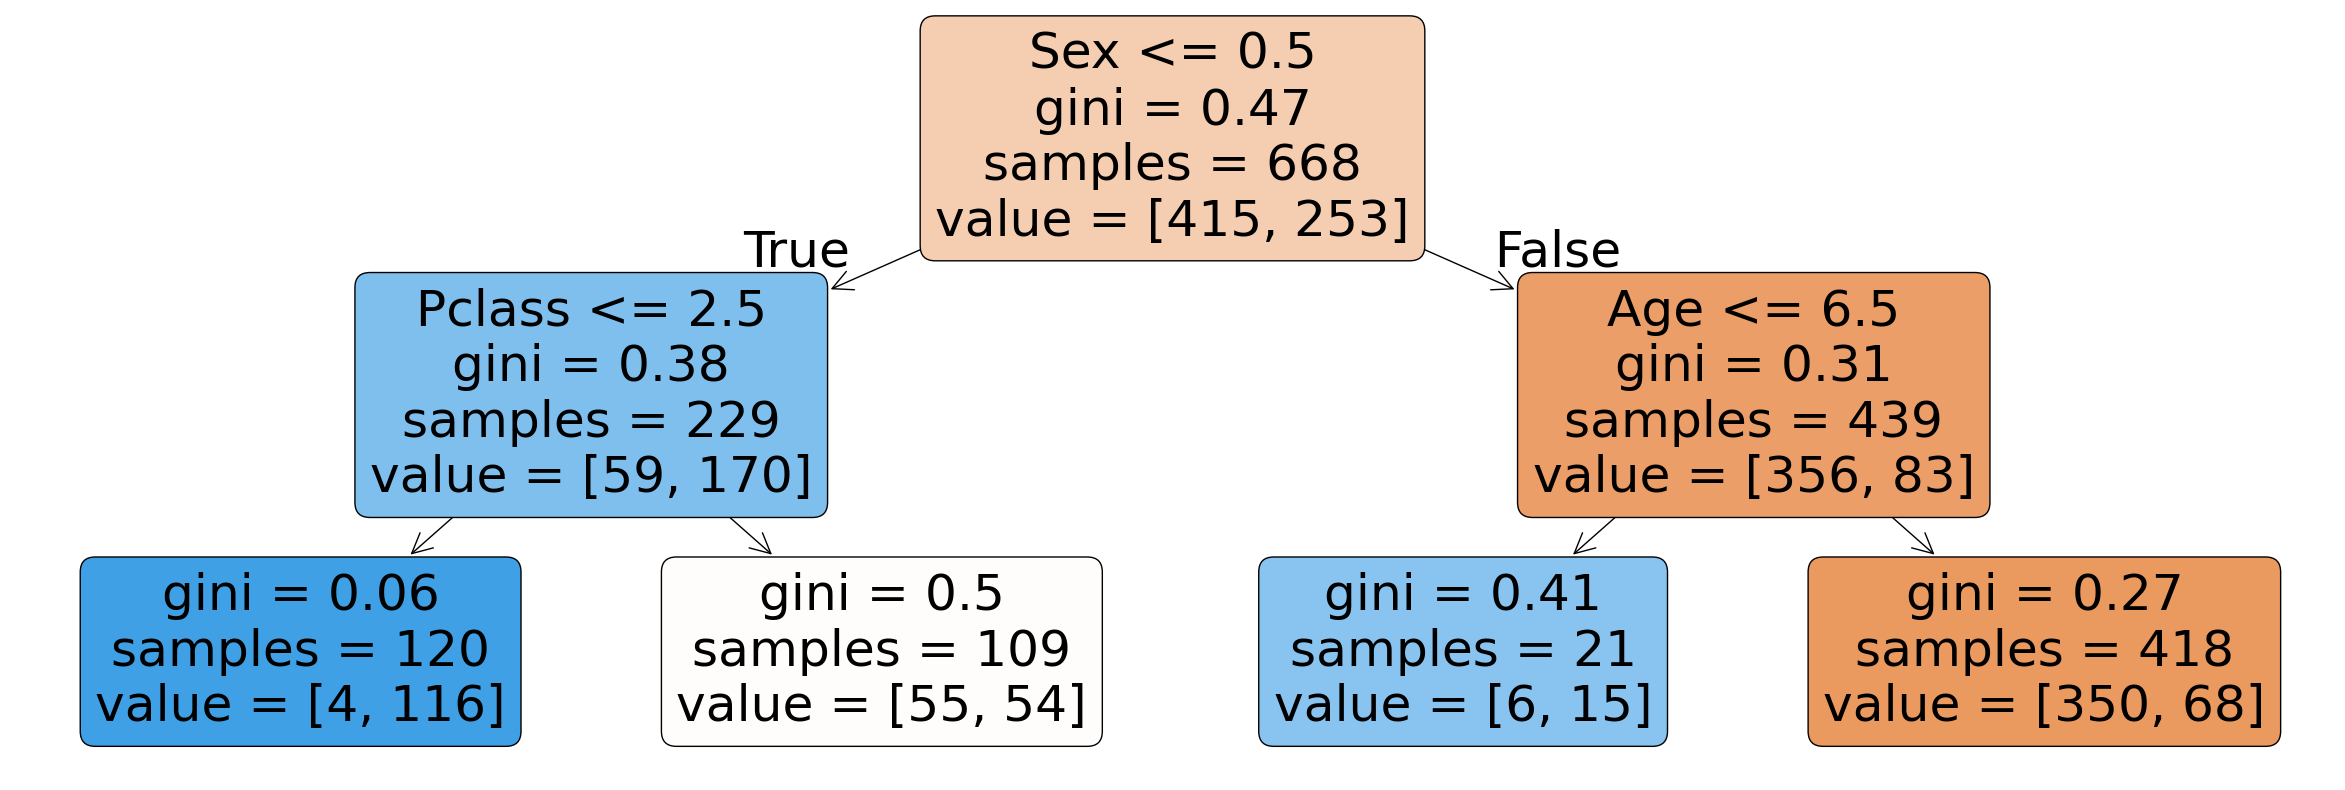

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(30,10))
plot_tree(m, feature_names=trn_xs.columns, filled=True, rounded=True, precision=2)
plt.show()

In [34]:
def gini(cond):
    act = df.loc[cond, dep]
    return 1 - act.mean()**2 - (1-act).mean()**2

In [35]:
gini(df.Sex=='female'), gini(df.Sex=='male')

(np.float64(0.3828350034484158), np.float64(0.3064437162277842))

In [36]:
mean_absolute_error(val_y, m.predict(val_xs))

0.2242152466367713

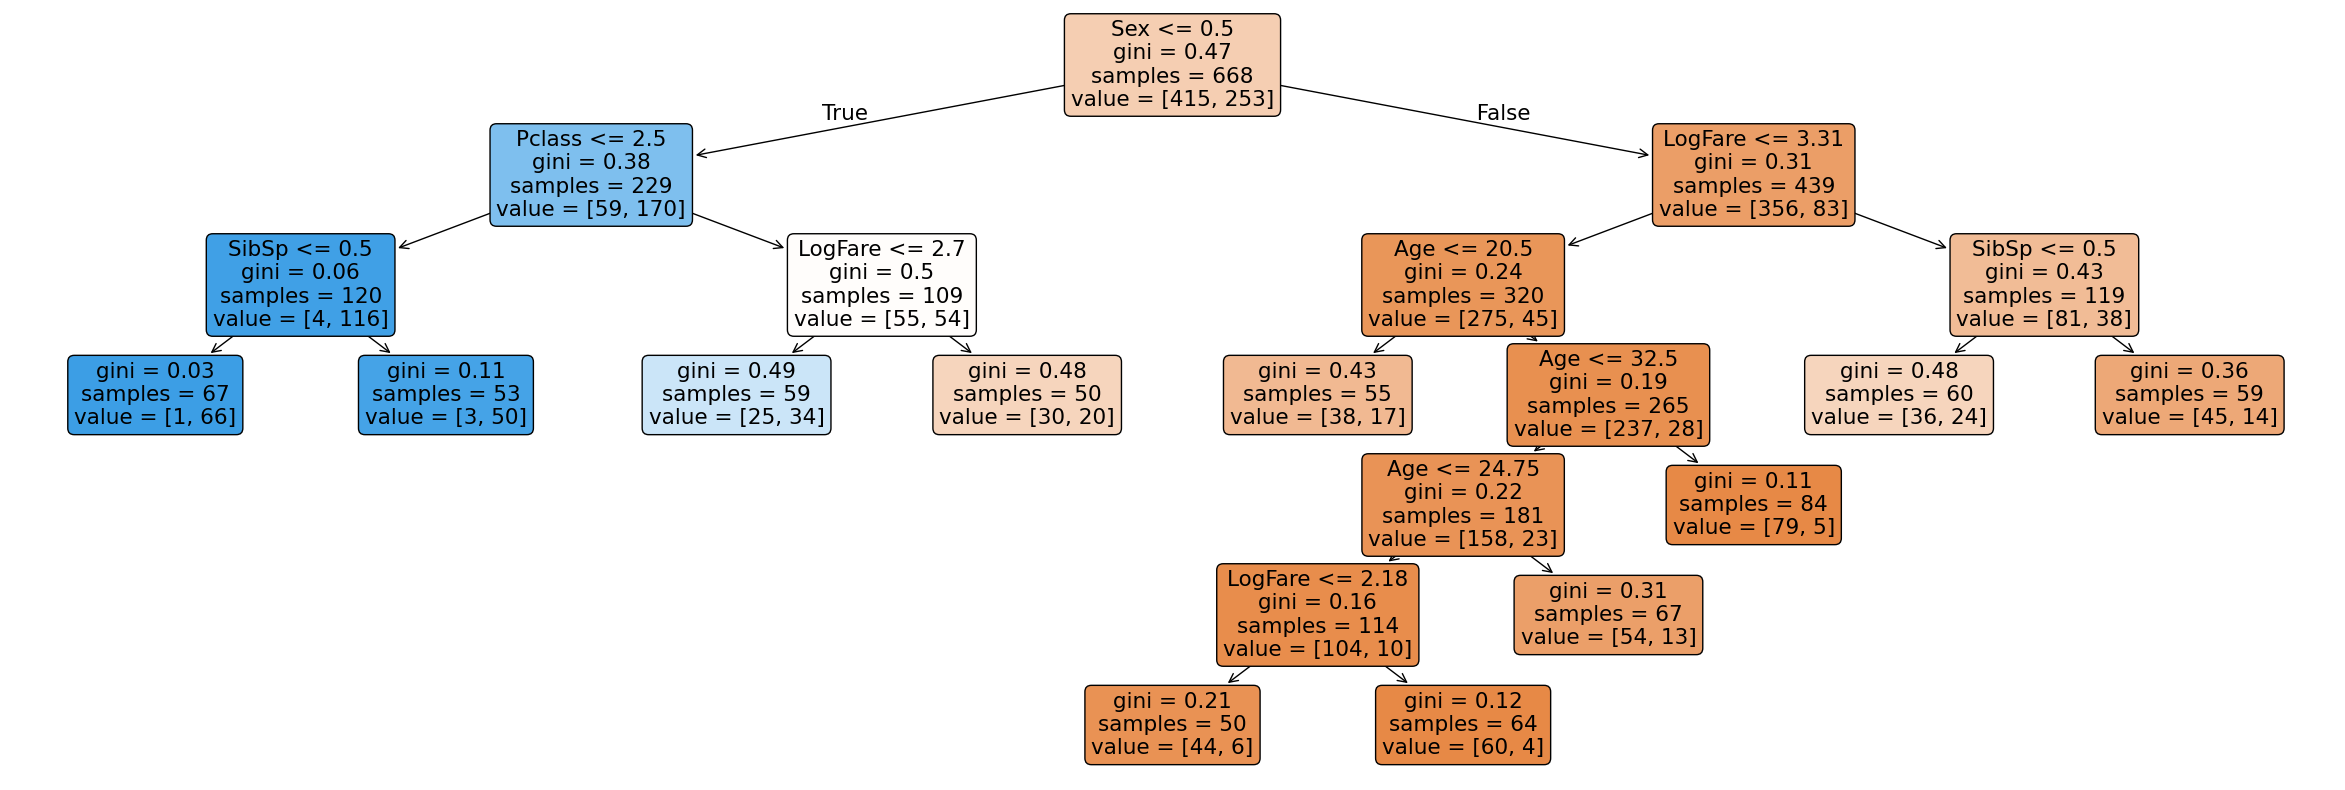

In [38]:
m = DecisionTreeClassifier(min_samples_leaf=50)
m.fit(trn_xs, trn_y)

plt.figure(figsize=(30,10))
plot_tree(m, feature_names=trn_xs.columns, filled=True, rounded=True, precision=2)
plt.show()

In [39]:
mean_absolute_error(val_y, m.predict(val_xs))

0.18385650224215247

In [41]:
tst_df[cats] = tst_df[cats].apply(lambda x: x.cat.codes)
tst_xs,_ = xs_y(tst_df)

def subm(preds, suff):
    tst_df['Survived'] = preds
    sub_df = tst_df[['PassengerId','Survived']]
    sub_df.to_csv(f'sub-{suff}.csv', index=False)

subm(m.predict(tst_xs), 'tree')


In [42]:
df.Embarked.head()


0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: category
Categories (3, str): ['C', 'Q', 'S']

In [43]:
df.Embarked.cat.codes.head()

0    2
1    0
2    2
3    2
4    2
dtype: int8

In [44]:
#in this the random forest

In [45]:
def get_tree(prop=0.75):
    n = len(trn_y)
    idxs = random.choice(n, int(n*prop))
    return DecisionTreeClassifier(min_samples_leaf=5).fit(trn_xs.iloc[idxs], trn_y.iloc[idxs])

In [46]:
trees = [get_tree() for t in range(100)]

In [47]:
all_probs = [t.predict(val_xs) for t in trees]
avg_probs = np.stack(all_probs).mean(0)

mean_absolute_error(val_y, avg_probs)

0.22735426008968612

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(100, min_samples_leaf=5)
rf.fit(trn_xs, trn_y);
mean_absolute_error(val_y, rf.predict(val_xs))

0.18834080717488788

In [49]:
subm(rf.predict(tst_xs), 'rf')

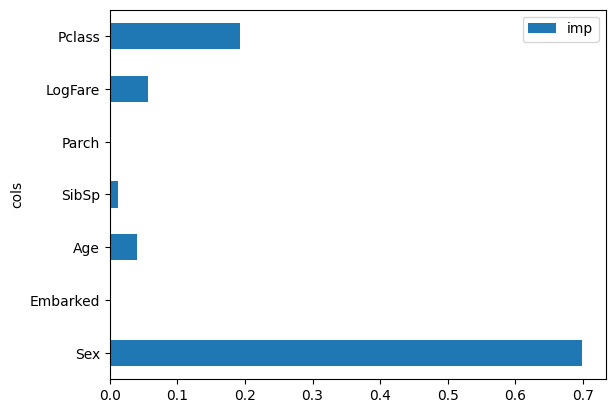

In [50]:
pd.DataFrame(dict(cols=trn_xs.columns, imp=m.feature_importances_)).plot('cols', 'imp', 'barh');

In [51]:
#First Steps: Road to the Top, Part 1

In [1]:
# install fastkaggle if not available
try: import fastkaggle
except ModuleNotFoundError:
    !pip install -Uq fastkaggle

from fastkaggle import *


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from pathlib import Path

path = Path(r"C:\Users\modin\OneDrive\Documents\my-internshipML\paddy-disease-classification")

In [12]:
print((path/'train (1).csv').exists())
print((path/'train_images').exists())
print((path/'test_images').exists())

True
True
True


In [13]:
path

WindowsPath('C:/Users/modin/OneDrive/Documents/my-internshipML/paddy-disease-classification')

In [14]:
from fastai.vision.all import *
set_seed(42)

path.ls()

[Path('C:/Users/modin/OneDrive/Documents/my-internshipML/paddy-disease-classification/sample_submission.csv'), Path('C:/Users/modin/OneDrive/Documents/my-internshipML/paddy-disease-classification/test_images'), Path('C:/Users/modin/OneDrive/Documents/my-internshipML/paddy-disease-classification/test_images.zip'), Path('C:/Users/modin/OneDrive/Documents/my-internshipML/paddy-disease-classification/train (1).csv'), Path('C:/Users/modin/OneDrive/Documents/my-internshipML/paddy-disease-classification/train_images'), Path('C:/Users/modin/OneDrive/Documents/my-internshipML/paddy-disease-classification/train_images.zip')]

In [15]:
trn_path = path/'train_images'
files = get_image_files(trn_path)

(480, 640)


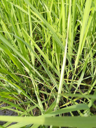

In [16]:
img = PILImage.create(files[0])
print(img.size)
img.to_thumb(128)

In [17]:
from fastcore.parallel import *

def f(o): return PILImage.create(o).size
sizes = parallel(f, files, n_workers=8)
pd.Series(sizes).value_counts()

Due to IPython and Windows limitation, python multiprocessing isn't available now.
So `max_workers` has to be changed to 0 to avoid getting stuck


(480, 640)    10403
(640, 480)        4
Name: count, dtype: int64

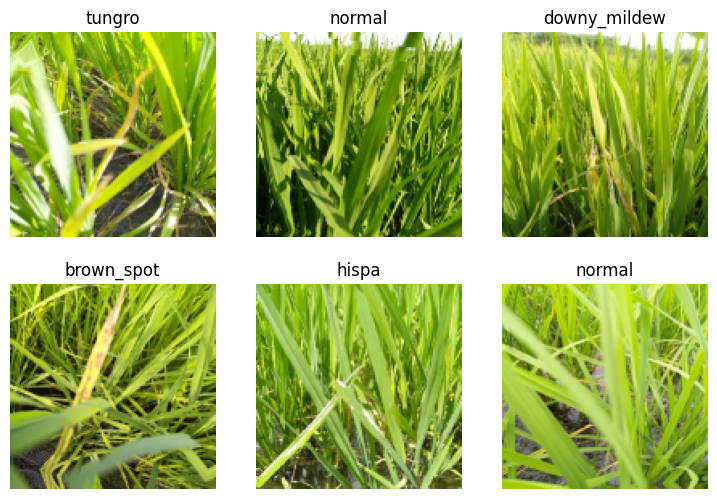

In [18]:
dls = ImageDataLoaders.from_folder(trn_path, valid_pct=0.2, seed=42,
    item_tfms=Resize(480, method='squish'),
    batch_tfms=aug_transforms(size=128, min_scale=0.75))

dls.show_batch(max_n=6)


In [7]:
from fastai.vision.all import *


In [9]:
path = Path(r"C:\Users\modin\OneDrive\Documents\my-internshipML\paddy-disease-classification")


In [10]:
dls = ImageDataLoaders.from_folder(
    path/'train_images',
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224)
)